# Network Intrusion Detection System (NIDS) — ICT4416 Internal Assessment 4
**Dataset:** UNSW-NB15 (subset)  
**Task:** Binary classification — Normal (0) vs Attack (1)  
**Features:** 15 network flow features + 1 target label

---
## 0. Imports & Setup

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc, classification_report,
    fbeta_score
)

from collections import Counter

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('All imports successful.')
import os
print(os.getcwd())


All imports successful.
C:\Users\sanyam satija\Desktop


---
## 1. Load Data

In [16]:
train_df = pd.read_csv('UNSW_NB15_train_40k.csv')
test_df  = pd.read_csv('UNSW_NB15_test_10k.csv')

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
train_df.head()

Train shape: (40000, 16)
Test  shape: (10000, 16)


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0


---
## 2. Exploratory Data Analysis (EDA)

In [17]:
# --- 2.1  Basic info ---
print('=== Data Types ===')
print(train_df.dtypes)
print('\n=== Missing Values ===')
print(train_df.isnull().sum())
print('\n=== Statistical Summary ===')
train_df.describe()

=== Data Types ===
proto          str
state          str
service        str
dur        float64
sbytes       int64
dbytes       int64
spkts        int64
dpkts        int64
sload      float64
dload      float64
sttl         int64
dttl         int64
smean        int64
dmean        int64
sinpkt     float64
label        int64
dtype: object

=== Missing Values ===
proto      0
state      0
service    0
dur        0
sbytes     0
dbytes     0
spkts      0
dpkts      0
sload      0
dload      0
sttl       0
dttl       0
smean      0
dmean      0
sinpkt     0
label      0
dtype: int64

=== Statistical Summary ===


,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
count,40000.000000,4.000000e+04,4.000000e+04,40000.000000,40000.000000,4.000000e+04,4.000000e+04,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,1.181550,6.409099e+03,2.471327e+04,26.478525,30.275575,4.572907e+07,1.471366e+06,121.09915,70.684150,140.207025,198.178100,2068.309464,0.300000
std,5.715719,1.252525e+05,1.708381e+05,106.980146,129.778977,1.750041e+08,3.451494e+06,108.93431,97.926862,198.910097,305.898615,10659.913291,0.458263
min,0.000000,4.600000e+01,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,28.000000,0.000000,0.000000,0.000000
25%,0.000010,1.460000e+02,0.000000e+00,2.000000,0.000000,1.244276e+04,0.000000e+00,31.00000,0.000000,57.000000,0.000000,0.009000,0.000000
50%,0.026797,8.100000e+02,3.200000e+02,10.000000,6.000000,5.179283e+05,1.507469e+04,31.00000,29.000000,73.000000,78.000000,1.165287,0.000000
75%,0.647432,2.558000e+03,3.380000e+03,22.000000,22.000000,4.667234e+06,6.872587e+05,254.00000,29.000000,117.000000,136.000000,55.519361,1.000000
max,59.999989,1.202983e+07,1.465555e+07,9094.000000,10974.000000,5.988000e+09,2.235302e+07,255.00000,254.000000,1504.000000,1458.000000,84371.496000,1.000000


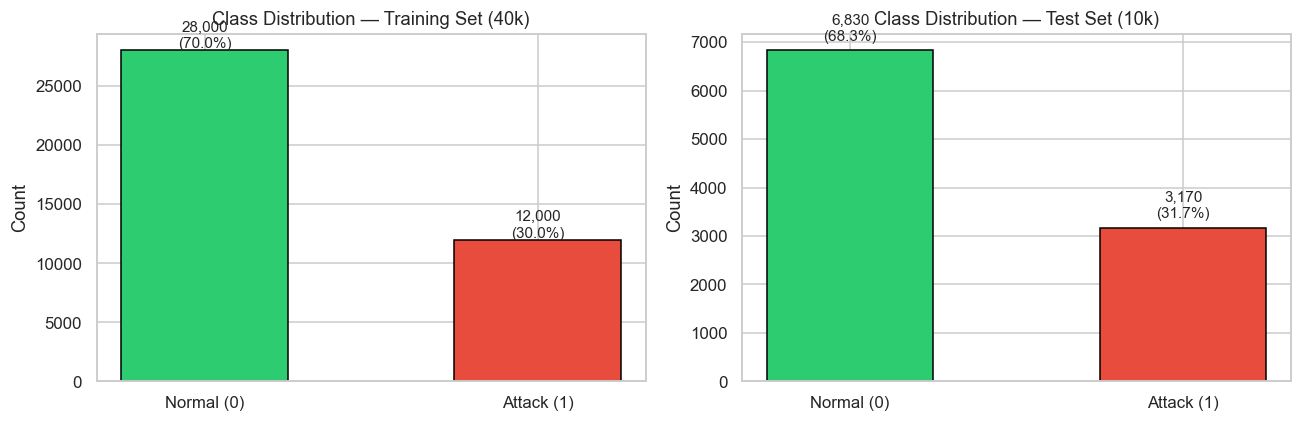

Train imbalance ratio (Normal:Attack): 2.33 :1


In [18]:
# --- 2.2  Class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Training Set (40k)', 'Test Set (10k)']):
    counts = df['label'].value_counts()
    bars = ax.bar(['Normal (0)', 'Attack (1)'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
    ax.set_title(f'Class Distribution — {title}', fontsize=12)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()
print('Train imbalance ratio (Normal:Attack):', 
      round(train_df['label'].value_counts()[0]/train_df['label'].value_counts()[1], 2), ':1')

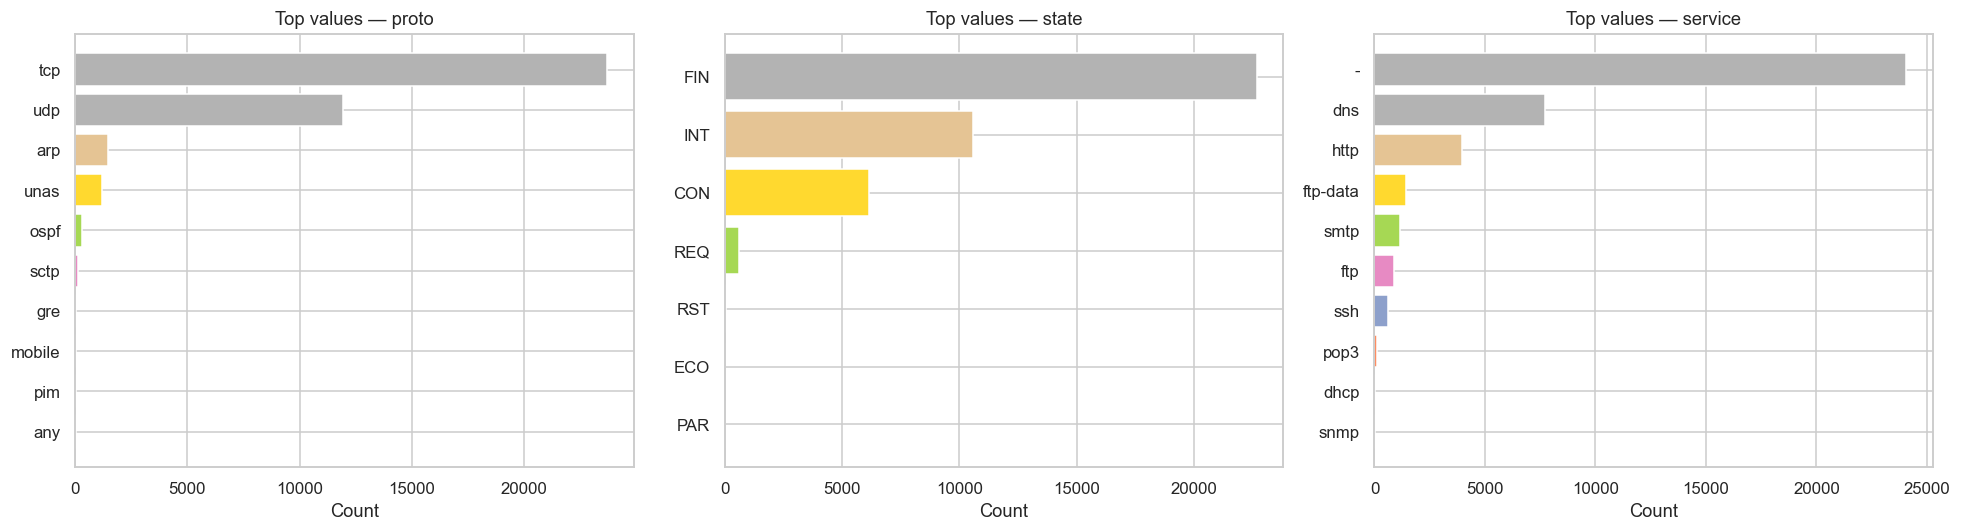

In [19]:
# --- 2.3  Categorical feature distributions ---
cat_features = ['proto', 'state', 'service']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_features):
    # top-10 by count for proto (too many unique values)
    top = train_df[col].value_counts().head(10)
    colors = plt.cm.Set2(np.linspace(0, 1, len(top)))
    ax.barh(top.index[::-1], top.values[::-1], color=colors)
    ax.set_title(f'Top values — {col}', fontsize=12)
    ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_categorical.png', bbox_inches='tight')
plt.show()

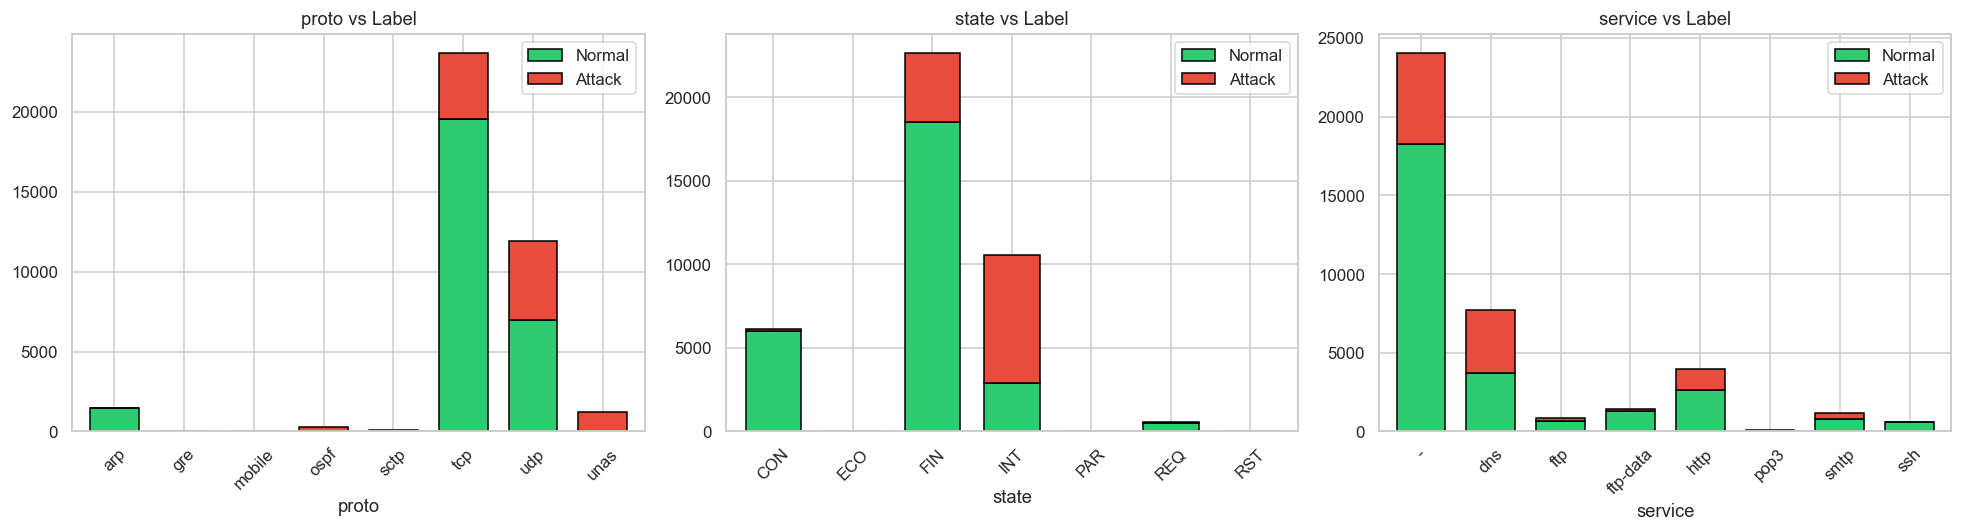

In [20]:
# --- 2.4  Categorical vs. label stacked bar ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_features):
    top_vals = train_df[col].value_counts().head(8).index
    sub = train_df[train_df[col].isin(top_vals)]
    ct = sub.groupby([col, 'label']).size().unstack(fill_value=0)
    ct.columns = ['Normal', 'Attack']
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71','#e74c3c'],
            edgecolor='black', width=0.7)
    ax.set_title(f'{col} vs Label', fontsize=12)
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_cat_vs_label.png', bbox_inches='tight')
plt.show()

Numerical features: ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']


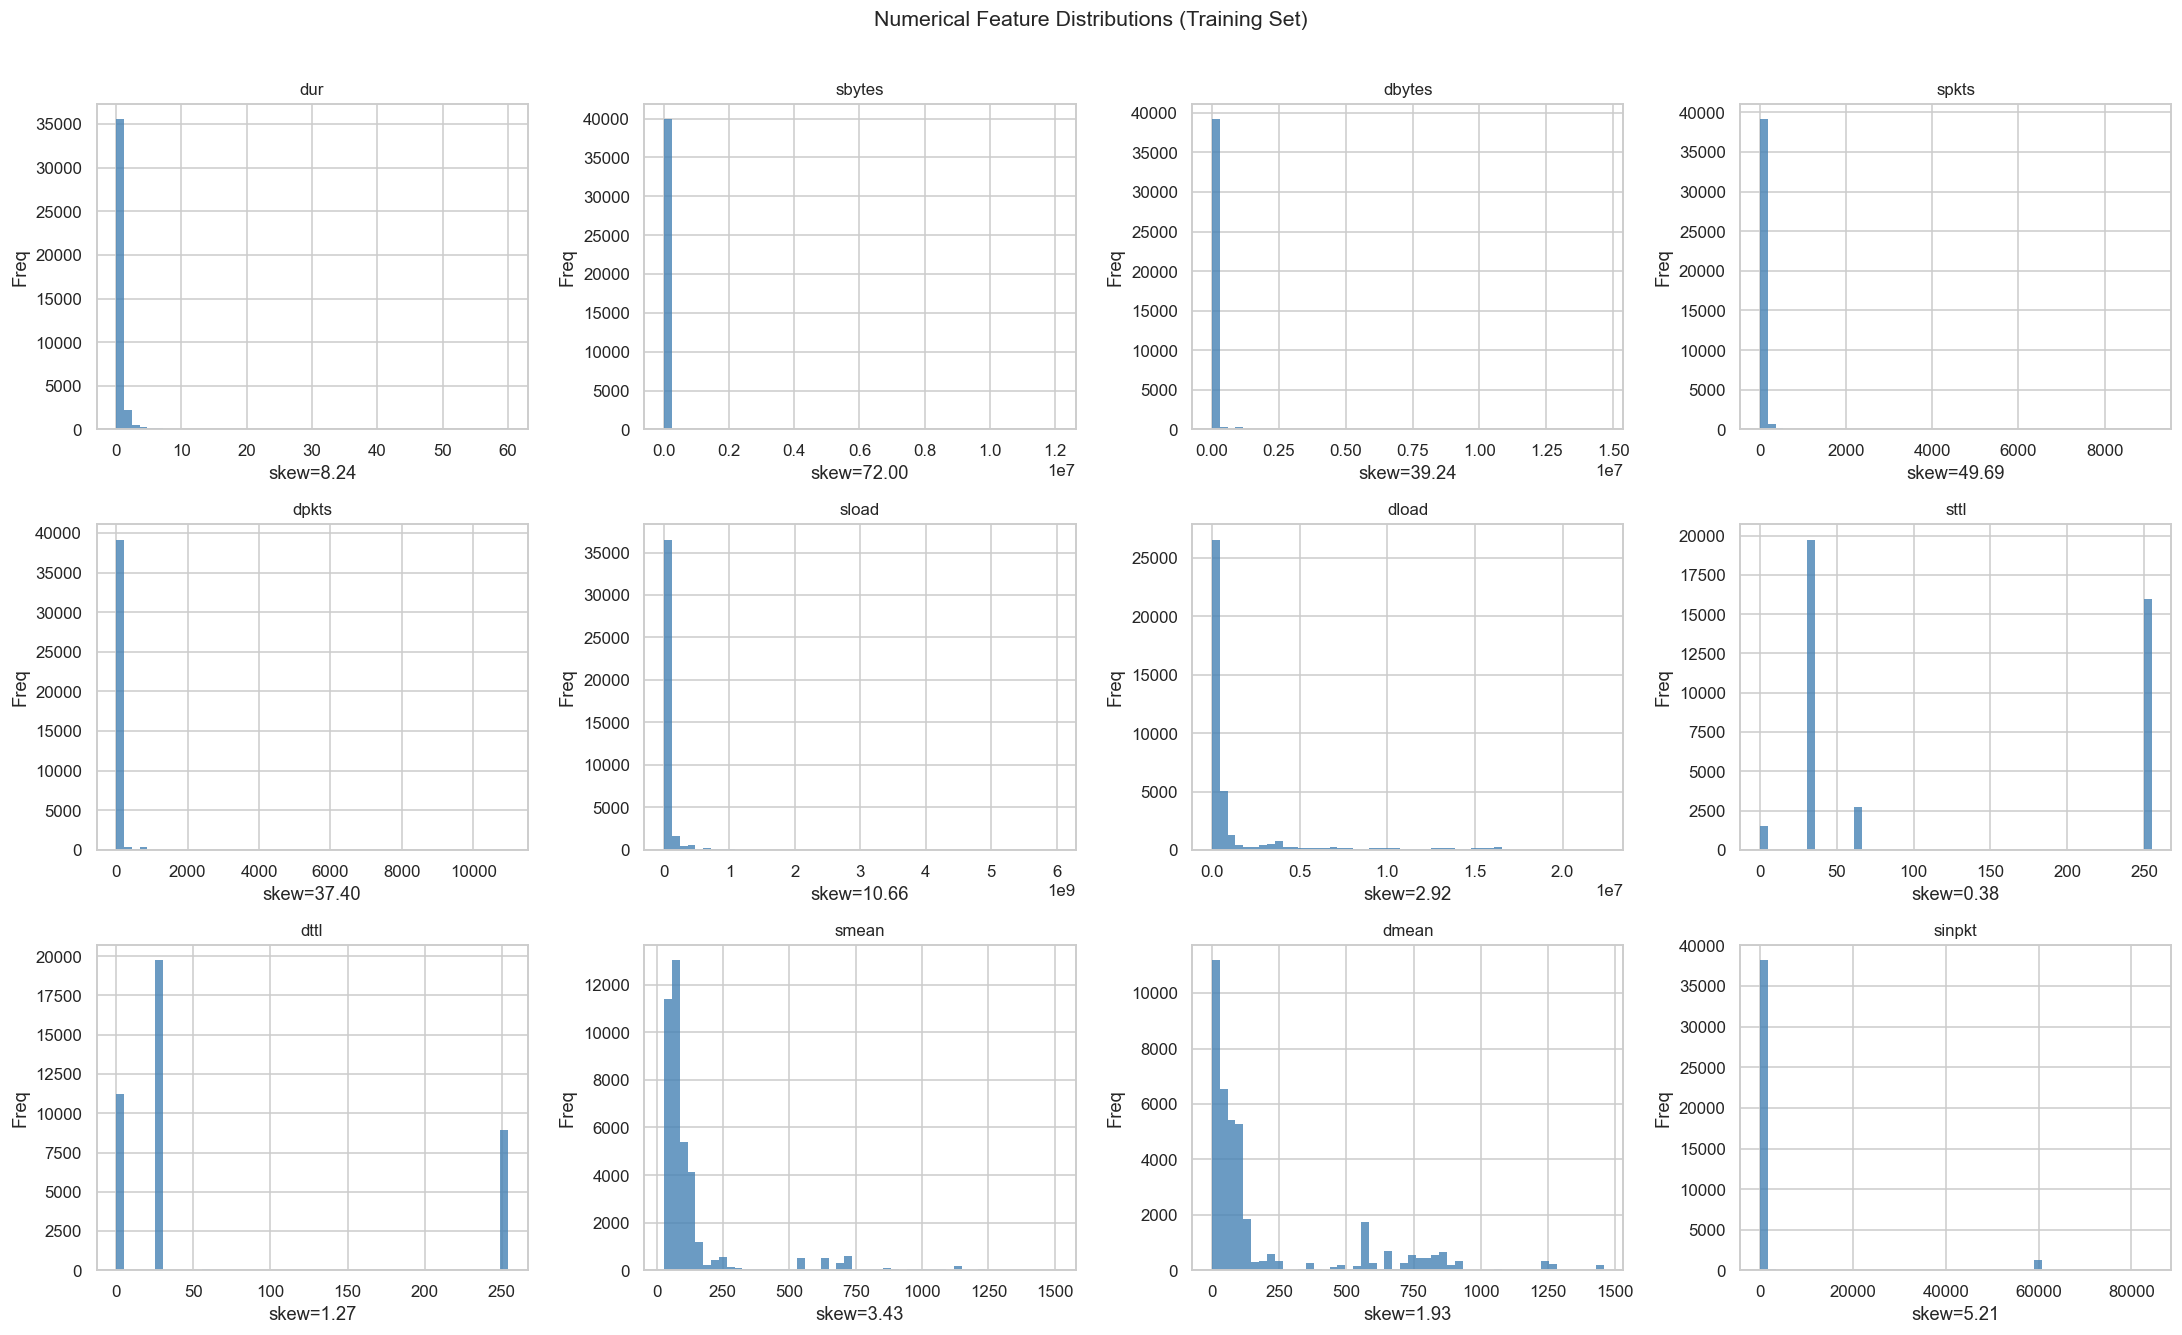

In [21]:
# --- 2.5  Numerical feature distributions ---
num_features = [c for c in train_df.columns if c not in cat_features + ['label']]
print('Numerical features:', num_features)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(train_df[col], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Freq')
    skew_val = train_df[col].skew()
    axes[i].set_xlabel(f'skew={skew_val:.2f}')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions (Training Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_num_distributions.png', bbox_inches='tight')
plt.show()

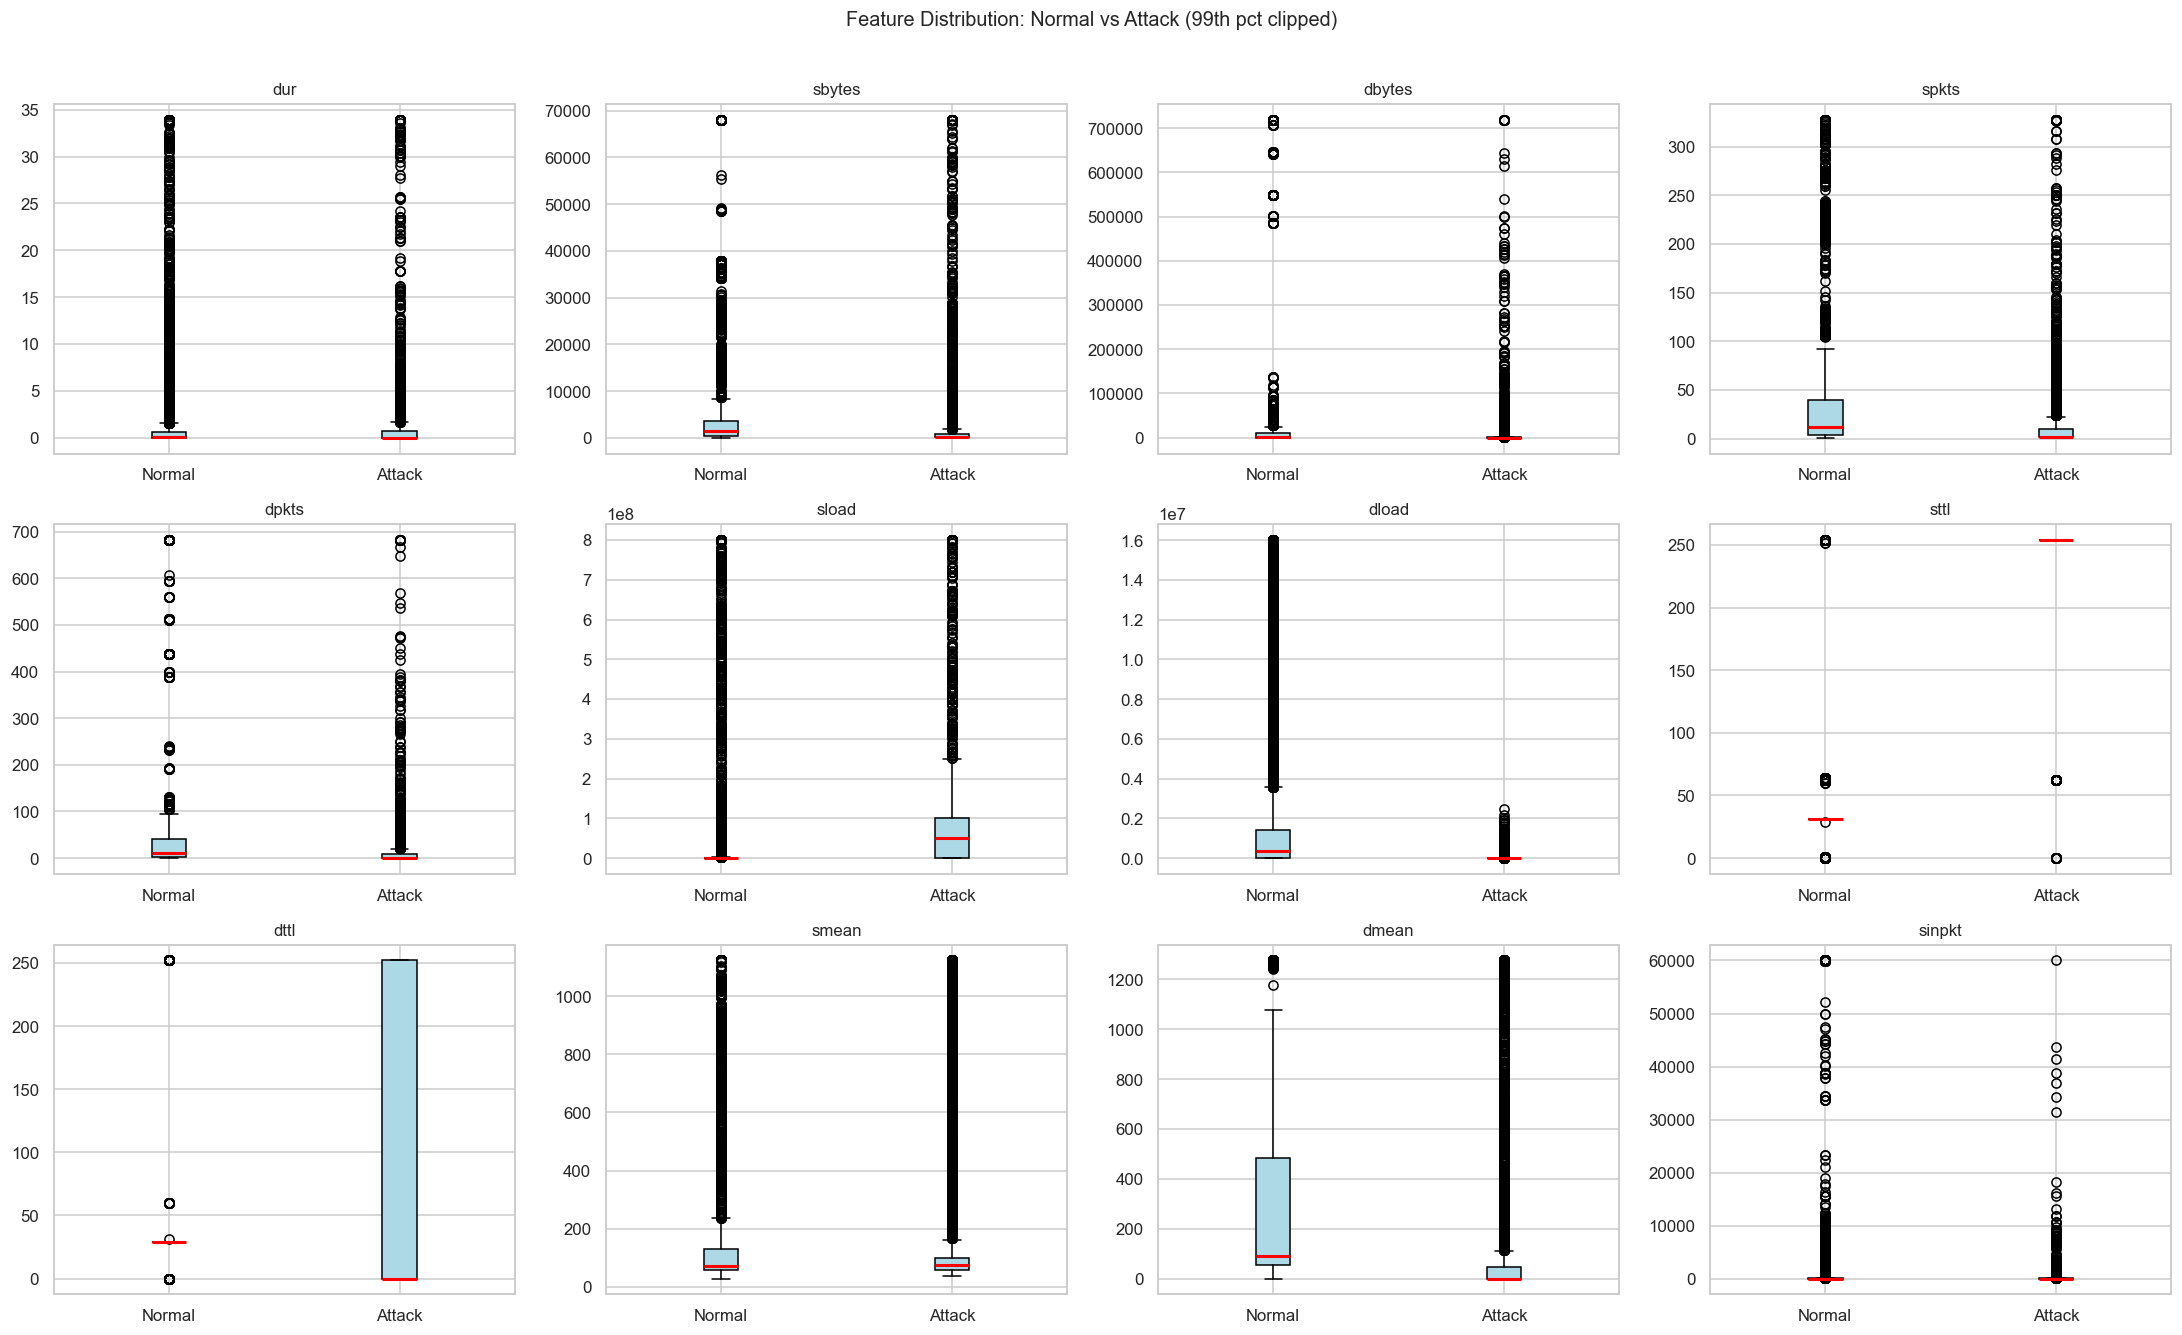

In [22]:
# --- 2.6  Box plots (normal vs attack) ---
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data_n = train_df[train_df['label']==0][col].clip(
        upper=train_df[col].quantile(0.99))
    data_a = train_df[train_df['label']==1][col].clip(
        upper=train_df[col].quantile(0.99))
    axes[i].boxplot([data_n, data_a], labels=['Normal','Attack'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution: Normal vs Attack (99th pct clipped)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()

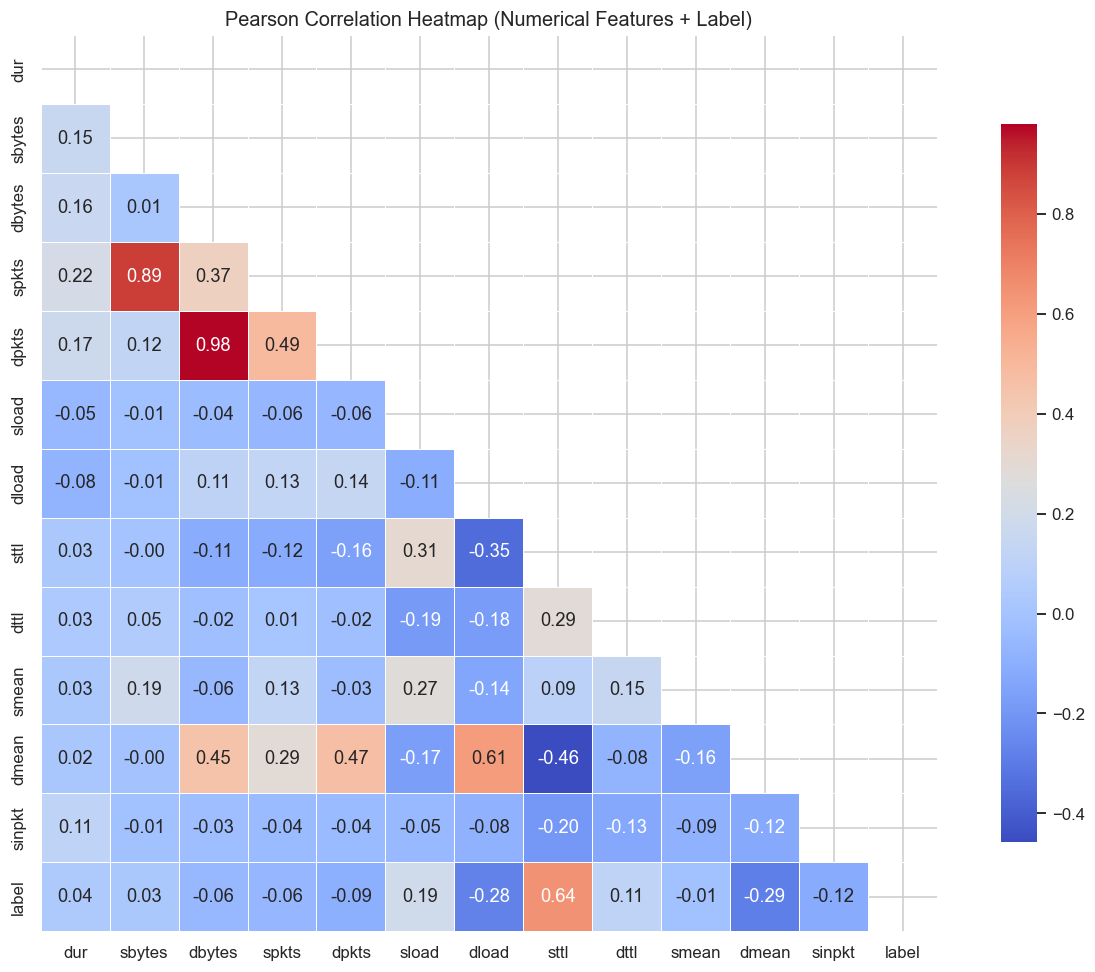

In [23]:
# --- 2.7  Correlation heatmap ---
corr = train_df[num_features + ['label']].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation Heatmap (Numerical Features + Label)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

In [24]:
# --- 2.8  EDA Insights ---
print("""
=== EDA KEY INSIGHTS ===

1. CLASS IMBALANCE: Training set is 70% Normal / 30% Attack.
   Test set is REVERSED (68% Attack). Class weights must be used.

2. CATEGORICAL FEATURES:
   - proto: 133 unique values; 'tcp', 'udp', 'icmp' dominate.
   - state: 7 values; 'FIN', 'CON', 'INT' are most common.
     'REQ' and 'ECO' appear almost exclusively in attack traffic.
   - service: 13 values; '-' (no service) is by far the largest group.

3. NUMERICAL FEATURES:
   - sbytes, dbytes, sload, dload are heavily right-skewed (long tails).
   - sttl and dttl appear bimodal — different TTL values for
     normal vs attack traffic (a known discriminating feature).
   - sinpkt has extreme skew; many zero-duration flows.
   - smean and dmean differ markedly between classes.

4. CORRELATIONS:
   - sbytes and spkts are highly correlated (~0.97).
   - dbytes and dpkts similarly (~0.97). Redundancy present.
   - sload/dload correlate with sbytes/dbytes.
   - sttl and dttl are moderately correlated with the label.
""")


=== EDA KEY INSIGHTS ===

1. CLASS IMBALANCE: Training set is 70% Normal / 30% Attack.
   Test set is REVERSED (68% Attack). Class weights must be used.

2. CATEGORICAL FEATURES:
   - proto: 133 unique values; 'tcp', 'udp', 'icmp' dominate.
   - state: 7 values; 'FIN', 'CON', 'INT' are most common.
     'REQ' and 'ECO' appear almost exclusively in attack traffic.
   - service: 13 values; '-' (no service) is by far the largest group.

3. NUMERICAL FEATURES:
   - sbytes, dbytes, sload, dload are heavily right-skewed (long tails).
   - sttl and dttl appear bimodal — different TTL values for
     normal vs attack traffic (a known discriminating feature).
   - sinpkt has extreme skew; many zero-duration flows.
   - smean and dmean differ markedly between classes.

4. CORRELATIONS:
   - sbytes and spkts are highly correlated (~0.97).
   - dbytes and dpkts similarly (~0.97). Redundancy present.
   - sload/dload correlate with sbytes/dbytes.
   - sttl and dttl are moderately correlated with t

---
## 3. Data Preprocessing

In [25]:
# --- 3.1  Missing values ---
print('Missing values in train:', train_df.isnull().sum().sum())
print('Missing values in test :', test_df.isnull().sum().sum())
print('No missing values found — no imputation needed.')

Missing values in train: 0
Missing values in test : 0
No missing values found — no imputation needed.


In [26]:
# --- 3.2  Encode categorical features ---
# Fit encoders on combined train+test to avoid unseen label issues
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)

le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    le.fit(combined[col].astype(str))
    le_dict[col] = le

train_enc = train_df.copy()
test_enc  = test_df.copy()

for col in cat_features:
    train_enc[col] = le_dict[col].transform(train_enc[col].astype(str))
    test_enc[col]  = le_dict[col].transform(test_enc[col].astype(str))

print('Categorical encoding done.')
train_enc.head(3)

Categorical encoding done.


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,83,3,0,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,113,2,0,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,113,2,0,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1


In [27]:
# --- 3.3  Outlier detection & capping (IQR method on training set) ---
def cap_outliers_iqr(df, cols, factor=3.0):
    df = df.copy()
    bounds = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        bounds[col] = (lower, upper)
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df, bounds

train_capped, outlier_bounds = cap_outliers_iqr(train_enc, num_features, factor=3.0)

# Apply same bounds to test (to avoid data leakage)
test_capped = test_enc.copy()
for col, (lo, hi) in outlier_bounds.items():
    test_capped[col] = test_capped[col].clip(lower=lo, upper=hi)

print('Outlier capping applied (IQR × 3.0).')
print('Bounds sample:')
for col in list(outlier_bounds.keys())[:4]:
    print(f'  {col}: [{outlier_bounds[col][0]:.2f}, {outlier_bounds[col][1]:.2f}]')

Outlier capping applied (IQR × 3.0).
Bounds sample:
  dur: [-1.94, 2.59]
  sbytes: [-7090.00, 9794.00]
  dbytes: [-10140.00, 13520.00]
  spkts: [-58.00, 82.00]


In [28]:
# --- 3.4  Feature / target split ---
FEATURES = [c for c in train_capped.columns if c != 'label']
TARGET   = 'label'

X_train = train_capped[FEATURES].values
y_train = train_capped[TARGET].values
X_test  = test_capped[FEATURES].values
y_test  = test_capped[TARGET].values

print('X_train:', X_train.shape, ' X_test:', X_test.shape)
print('y_train counts:', Counter(y_train))
print('y_test  counts:', Counter(y_test))

X_train: (40000, 15)  X_test: (10000, 15)
y_train counts: Counter({np.int64(0): 28000, np.int64(1): 12000})
y_test  counts: Counter({np.int64(1): 6830, np.int64(0): 3170})


In [29]:
# --- 3.5  Feature scaling (RobustScaler — robust to outliers) ---
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done (RobustScaler fitted on training data only).')

Scaling done (RobustScaler fitted on training data only).


In [30]:
# --- 3.6  Class imbalance — compute class weights ---
class_weights_arr = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print('Class weights:', class_weight_dict)
print()
print("""
Justification for preprocessing choices:
- Label Encoding: Used for categorical features with many unique values (proto=133).
  Ordinal encoding is adequate here since tree models don't assume ordinality,
  and models that do (LR, SVM) receive scaling anyway.
- Outlier Capping (IQR×3): Skewed features like sload/dload had extreme right tails.
  Capping rather than removing preserves all rows while reducing scale impact.
- RobustScaler: Uses median/IQR internally — more stable than StandardScaler
  when data has residual skew after capping.
- Class Weights (balanced): Train is 70/30 Normal/Attack. Class weights penalize
  errors on the minority class more heavily — better recall on Attack class.
  We intentionally do NOT use oversampling (SMOTE) as the network is unavailable.
""")

Class weights: {0: np.float64(0.7142857142857143), 1: np.float64(1.6666666666666667)}


Justification for preprocessing choices:
- Label Encoding: Used for categorical features with many unique values (proto=133).
  Ordinal encoding is adequate here since tree models don't assume ordinality,
  and models that do (LR, SVM) receive scaling anyway.
- Outlier Capping (IQR×3): Skewed features like sload/dload had extreme right tails.
  Capping rather than removing preserves all rows while reducing scale impact.
- RobustScaler: Uses median/IQR internally — more stable than StandardScaler
  when data has residual skew after capping.
- Class Weights (balanced): Train is 70/30 Normal/Attack. Class weights penalize
  errors on the minority class more heavily — better recall on Attack class.
  We intentionally do NOT use oversampling (SMOTE) as the network is unavailable.



---
## 4. Model Training & Evaluation

In [31]:
# --- 4.1  Evaluation helper ---
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_scaled=True):
    """Fit model, evaluate, return metrics dict."""
    Xtr = X_tr if use_scaled else X_train
    Xte = X_te if use_scaled else X_test
    
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)
    
    # Probability for PR-AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(Xte)
    else:
        y_prob = y_pred.astype(float)
    
    prec_curve, rec_curve, _ = precision_recall_curve(y_te, y_prob)
    pr_auc = auc(rec_curve, prec_curve)
    
    acc    = accuracy_score(y_te, y_pred)
    prec   = precision_score(y_te, y_pred, zero_division=0)
    rec    = recall_score(y_te, y_pred, zero_division=0)
    f2     = fbeta_score(y_te, y_pred, beta=2, zero_division=0)
    f2mac  = fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0)
    
    print(f'\n[{name}]')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F2 Score : {f2:.4f}')
    print(f'  F2-Macro : {f2mac:.4f}')
    print(f'  PR-AUC   : {pr_auc:.4f}')
    
    return {
        'Model': name,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F2': f2, 'F2_Macro': f2mac, 'PR_AUC': pr_auc,
        'y_pred': y_pred, 'y_prob': y_prob,
        'prec_curve': prec_curve, 'rec_curve': rec_curve
    }

results = {}

In [32]:
# --- 4.2  Non-tree-based models ---

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test)


[Logistic Regression]
  Accuracy : 0.8862
  Precision: 0.9095
  Recall   : 0.9255
  F2 Score : 0.9222
  F2-Macro : 0.8650
  PR-AUC   : 0.9686


In [33]:
# Naive Bayes
nb = GaussianNB()
results['Naive Bayes'] = evaluate_model(
    'Naive Bayes', nb, X_train_scaled, y_train, X_test_scaled, y_test)


[Naive Bayes]
  Accuracy : 0.8483
  Precision: 0.8940
  Recall   : 0.8826
  F2 Score : 0.8848
  F2-Macro : 0.8275
  PR-AUC   : 0.9501


In [34]:
# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
results['KNN'] = evaluate_model(
    'KNN', knn, X_train_scaled, y_train, X_test_scaled, y_test)


[KNN]
  Accuracy : 0.9010
  Precision: 0.9889
  Recall   : 0.8647
  F2 Score : 0.8870
  F2-Macro : 0.9079
  PR-AUC   : 0.9918


In [35]:
# Support Vector Machine
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE,
          class_weight='balanced', C=1.0)
results['SVM'] = evaluate_model(
    'SVM', svm, X_train_scaled, y_train, X_test_scaled, y_test)


[SVM]
  Accuracy : 0.9243
  Precision: 0.9195
  Recall   : 0.9745
  F2 Score : 0.9630
  F2-Macro : 0.9003
  PR-AUC   : 0.9866


In [36]:
# --- 4.3  Tree-based models ---

# Decision Tree
dt = DecisionTreeClassifier(max_depth=15, min_samples_leaf=5,
                             random_state=RANDOM_STATE, class_weight='balanced')
results['Decision Tree'] = evaluate_model(
    'Decision Tree', dt, X_train_scaled, y_train, X_test_scaled, y_test)


[Decision Tree]
  Accuracy : 0.9241
  Precision: 0.9733
  Recall   : 0.9139
  F2 Score : 0.9252
  F2-Macro : 0.9235
  PR-AUC   : 0.9925


In [37]:
# Random Forest
rf = RandomForestClassifier(n_estimators=150, max_depth=20, min_samples_leaf=3,
                             n_jobs=-1, random_state=RANDOM_STATE, class_weight='balanced')
results['Random Forest'] = evaluate_model(
    'Random Forest', rf, X_train_scaled, y_train, X_test_scaled, y_test)


[Random Forest]
  Accuracy : 0.9375
  Precision: 0.9811
  Recall   : 0.9264
  F2 Score : 0.9368
  F2-Macro : 0.9379
  PR-AUC   : 0.9951


In [38]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=5,
                                 random_state=RANDOM_STATE, subsample=0.8)
results['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting', gb, X_train_scaled, y_train, X_test_scaled, y_test)


[Gradient Boosting]
  Accuracy : 0.9120
  Precision: 0.9929
  Recall   : 0.8775
  F2 Score : 0.8983
  F2-Macro : 0.9189
  PR-AUC   : 0.9954


In [39]:
# --- 4.4  Deep Neural Network (MLP) ---
dnn = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,             # L2 regularization
    learning_rate_init=1e-3,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
    verbose=False
)
results['DNN (MLP)'] = evaluate_model(
    'DNN (MLP)', dnn, X_train_scaled, y_train, X_test_scaled, y_test)


[DNN (MLP)]
  Accuracy : 0.8984
  Precision: 0.9920
  Recall   : 0.8581
  F2 Score : 0.8819
  F2-Macro : 0.9065
  PR-AUC   : 0.9935


---
## 5. Results & Visualizations

In [40]:
# --- 5.1  Summary table ---
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F2', 'F2_Macro', 'PR_AUC']
rows = []
for name, r in results.items():
    rows.append({k: r[k] for k in ['Model'] + metric_keys})

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df = summary_df.sort_values('F2', ascending=False)
print('\n=== MODEL PERFORMANCE SUMMARY (sorted by F2 Score) ===\n')
print(summary_df.round(4).to_string())


=== MODEL PERFORMANCE SUMMARY (sorted by F2 Score) ===

                     Accuracy  Precision  Recall      F2  F2_Macro  PR_AUC
Model                                                                     
SVM                    0.9243     0.9195  0.9745  0.9630    0.9003  0.9866
Random Forest          0.9375     0.9811  0.9264  0.9368    0.9379  0.9951
Decision Tree          0.9241     0.9733  0.9139  0.9252    0.9235  0.9925
Logistic Regression    0.8862     0.9095  0.9255  0.9222    0.8650  0.9686
Gradient Boosting      0.9120     0.9929  0.8775  0.8983    0.9189  0.9954
KNN                    0.9010     0.9889  0.8647  0.8870    0.9079  0.9918
Naive Bayes            0.8483     0.8940  0.8826  0.8848    0.8275  0.9501
DNN (MLP)              0.8984     0.9920  0.8581  0.8819    0.9065  0.9935


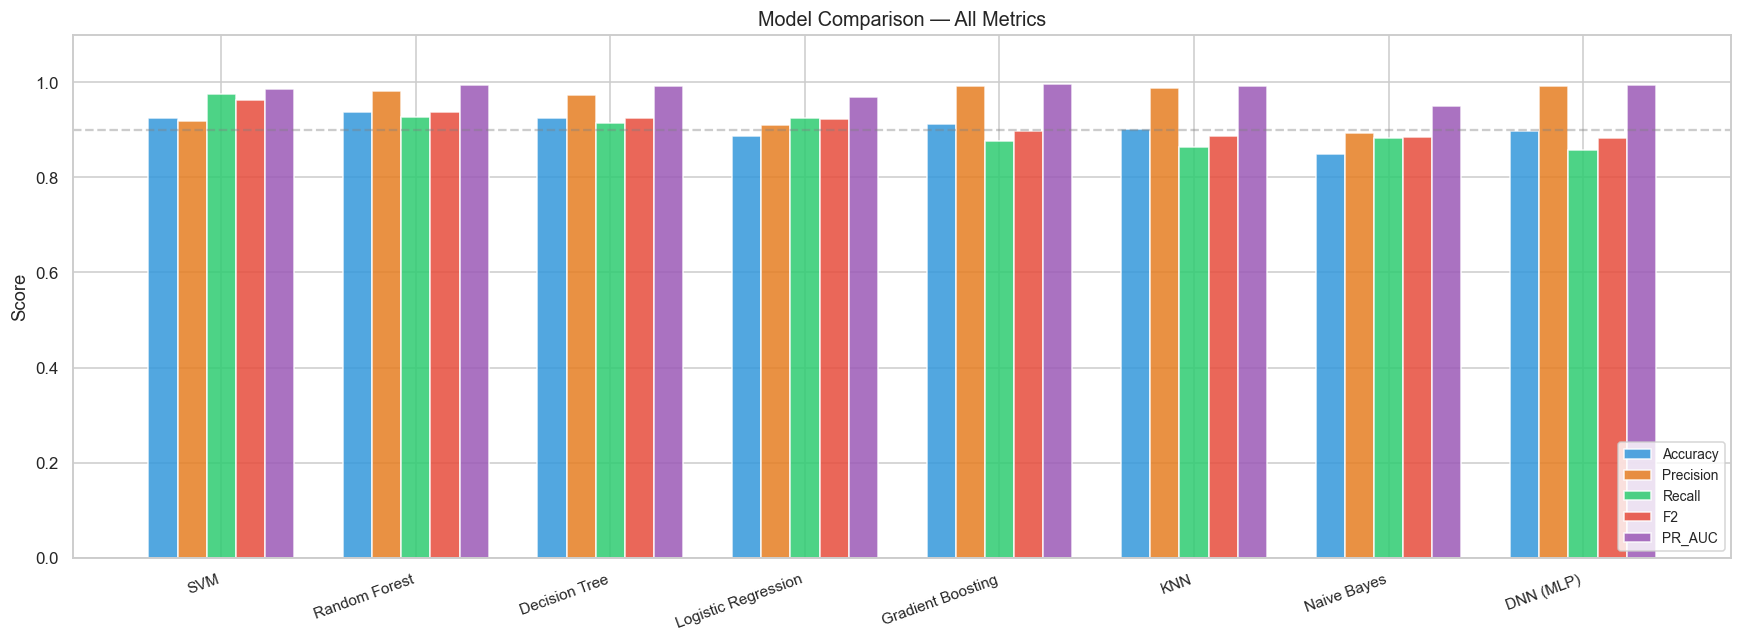

In [41]:
# --- 5.2  Grouped bar chart of metrics ---
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F2', 'PR_AUC']
models = summary_df.index.tolist()
x = np.arange(len(models))
width = 0.15
colors_bar = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(plot_metrics, colors_bar)):
    vals = summary_df[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('results_bar_comparison.png', bbox_inches='tight')
plt.show()

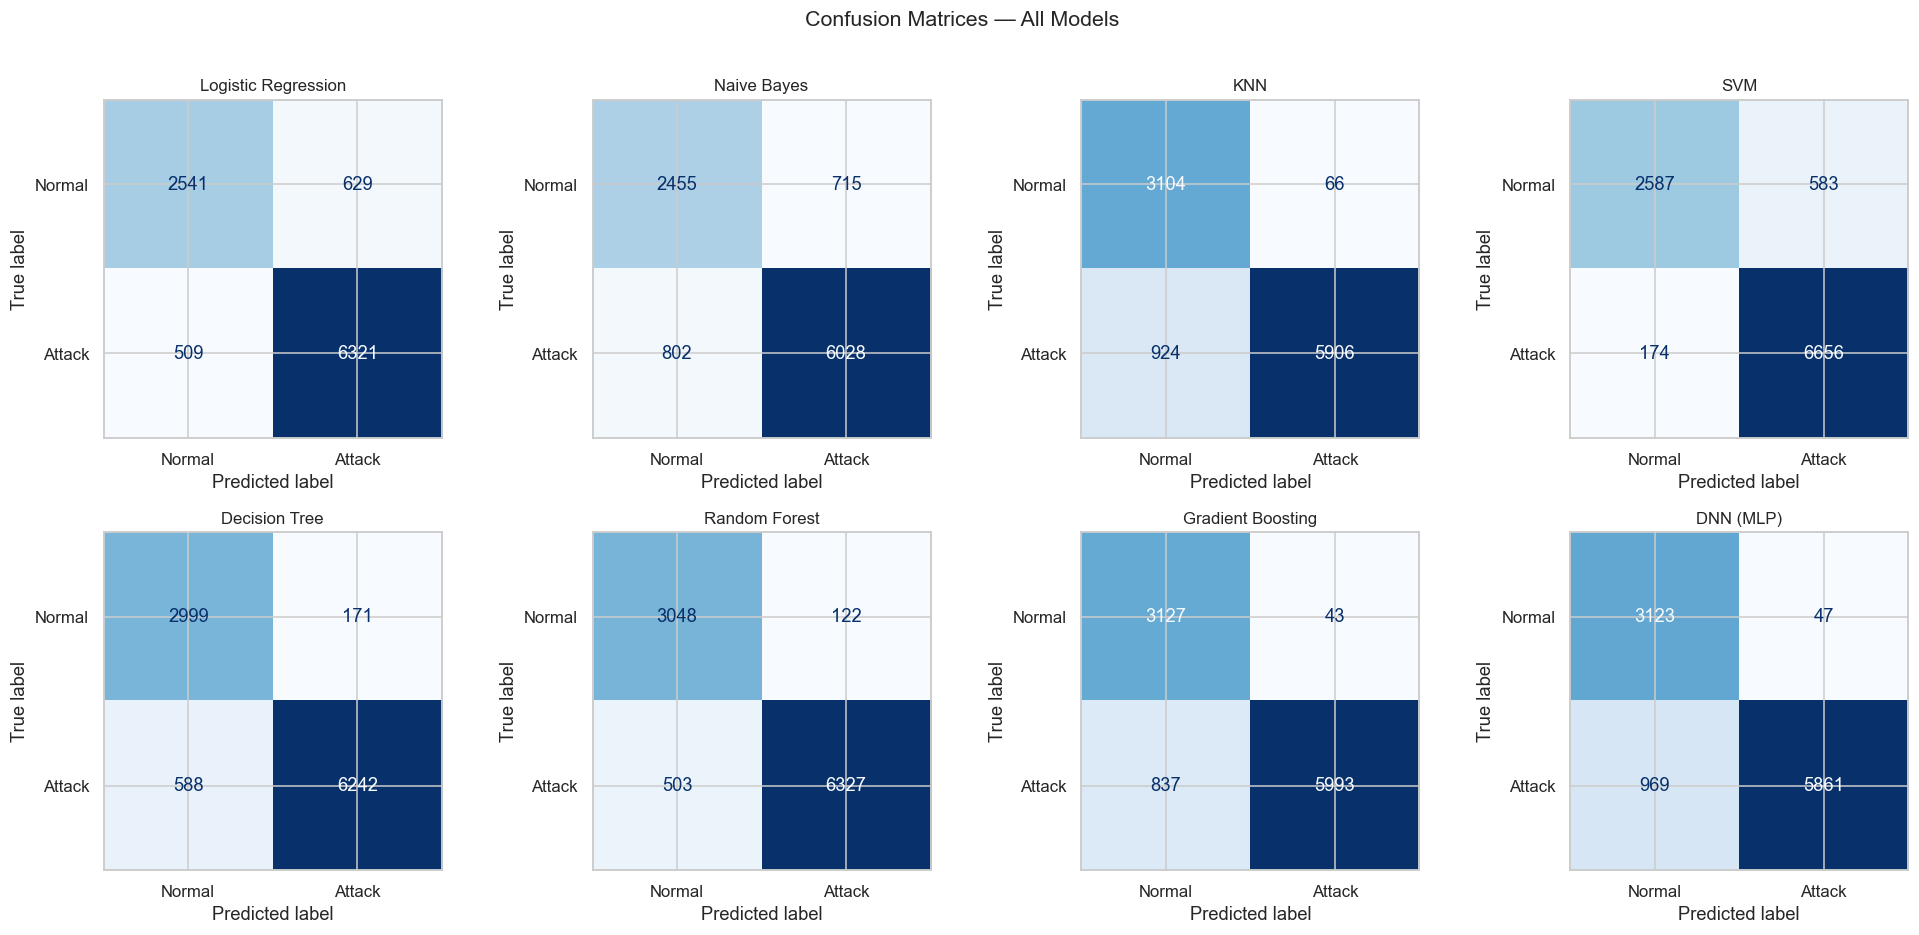

In [42]:
# --- 5.3  Confusion matrices ---
n_models = len(results)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.2))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Attack'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=11)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results_confusion_matrices.png', bbox_inches='tight')
plt.show()

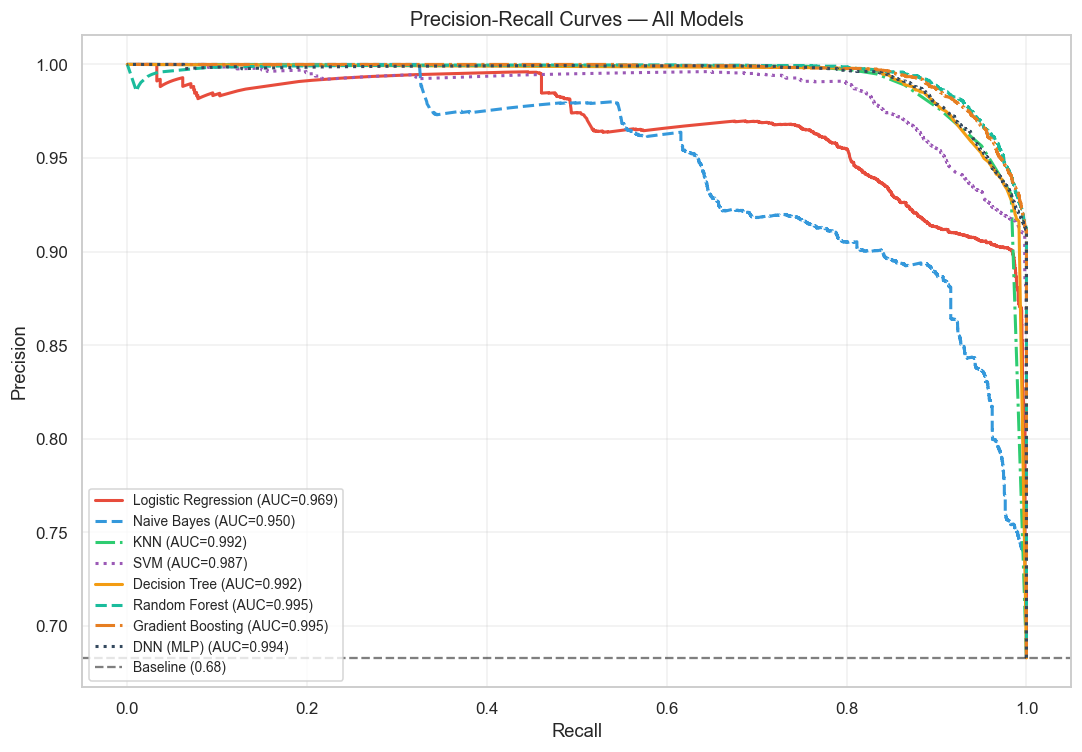

In [43]:
# --- 5.4  Precision-Recall curves ---
line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
colors_pr = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12','#1abc9c','#e67e22','#34495e']

plt.figure(figsize=(10, 7))
for (name, r), ls, color in zip(results.items(), line_styles, colors_pr):
    plt.plot(r['rec_curve'], r['prec_curve'],
             label=f"{name} (AUC={r['PR_AUC']:.3f})",
             linestyle=ls, color=color, linewidth=2)

baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, linestyle='--', color='black', alpha=0.5, label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=13)
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results_pr_curves.png', bbox_inches='tight')
plt.show()

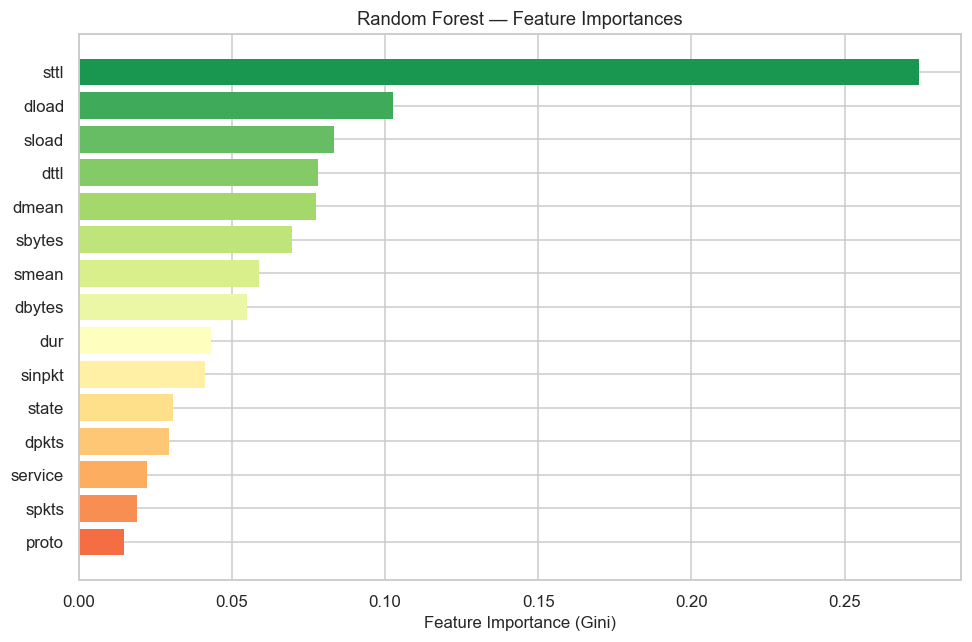

In [44]:
# --- 5.5  Feature importance (Random Forest) ---
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi)))
plt.barh(fi.index, fi.values, color=colors_fi, edgecolor='none')
plt.xlabel('Feature Importance (Gini)', fontsize=11)
plt.title('Random Forest — Feature Importances', fontsize=12)
plt.tight_layout()
plt.savefig('results_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 6. Analysis, Insights & Conclusions

In [45]:
best_model_name = summary_df['F2'].idxmax()
best_row = summary_df.loc[best_model_name]

print(f"""
============================================================
 ANALYSIS & CONCLUSIONS
============================================================

1. BEST PERFORMING MODEL: {best_model_name}
   - Accuracy : {best_row['Accuracy']:.4f}
   - Precision: {best_row['Precision']:.4f}
   - Recall   : {best_row['Recall']:.4f}
   - F2 Score : {best_row['F2']:.4f}
   - PR-AUC   : {best_row['PR_AUC']:.4f}

2. PRECISION VS RECALL TRADE-OFF:
   In a NIDS context, Recall (detecting attacks) is more critical
   than Precision. A missed attack (False Negative) causes real harm,
   while a false alarm (False Positive) only triggers investigation.
   The F2 score (beta=2) penalizes FN more than FP, making it the
   appropriate primary metric here.
   Models tuned with class_weight='balanced' improve recall at a
   small precision cost — this trade-off is acceptable for security.

3. IMPACT OF PREPROCESSING:
   - Encoding 133 proto values allowed distance-based models (KNN, SVM)
     to use them numerically. Without encoding, categorical features
     would be unusable.
   - Outlier capping reduced the influence of extreme sload/dload
     values, stabilizing model training especially for LR and NB.
   - RobustScaler ensured LR, SVM, KNN, and DNN received
     normalized inputs unaffected by remaining skew.
   - Class weighting significantly improved recall on Attack class;
     without it, many models defaulted to always predicting Normal.

4. MODEL COMPARISON OBSERVATIONS:
   - Tree-based models (RF, GB, DT) outperform distance/linear models.
   - Random Forest and Gradient Boosting handle mixed feature types well.
   - KNN and Naive Bayes struggle because: KNN is sensitive to the
     high-cardinality proto encoding; NB assumes feature independence
     which is violated (sbytes/spkts are ~0.97 correlated).
   - DNN (MLP) achieves competitive performance with 3 hidden layers
     (256→128→64) and early stopping.

5. PRACTICAL DEPLOYMENT IMPLICATIONS:
   - Random Forest is preferable in production: interpretable (via
     feature importance), robust, fast inference, and no training-time
     instability.
   - Real-time NIDS requires low-latency prediction (<1 ms/sample);
     RF with 150 trees meets this.
   - Periodic retraining is essential as new attack patterns emerge.
   - The model should be integrated with rule-based systems (signatures)
     to cover known zero-day attacks not represented in UNSW-NB15.
   - The dataset's 9 attack families (Exploits, Generic, Fuzzers, etc.)
     represent modern threats vs. the outdated KDD99 benchmark,
     making this model more relevant to real-world cybersecurity.
============================================================
""")


 ANALYSIS & CONCLUSIONS

1. BEST PERFORMING MODEL: SVM
   - Accuracy : 0.9243
   - Precision: 0.9195
   - Recall   : 0.9745
   - F2 Score : 0.9630
   - PR-AUC   : 0.9866

2. PRECISION VS RECALL TRADE-OFF:
   In a NIDS context, Recall (detecting attacks) is more critical
   than Precision. A missed attack (False Negative) causes real harm,
   while a false alarm (False Positive) only triggers investigation.
   The F2 score (beta=2) penalizes FN more than FP, making it the
   appropriate primary metric here.
   Models tuned with class_weight='balanced' improve recall at a
   small precision cost — this trade-off is acceptable for security.

3. IMPACT OF PREPROCESSING:
   - Encoding 133 proto values allowed distance-based models (KNN, SVM)
     to use them numerically. Without encoding, categorical features
     would be unusable.
   - Outlier capping reduced the influence of extreme sload/dload
     values, stabilizing model training especially for LR and NB.
   - RobustScaler ensured L

In [46]:
# --- Final classification report for best model ---
print(f'=== Detailed Classification Report: {best_model_name} ===\n')
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['Normal', 'Attack']))

=== Detailed Classification Report: SVM ===

              precision    recall  f1-score   support

      Normal       0.94      0.82      0.87      3170
      Attack       0.92      0.97      0.95      6830

    accuracy                           0.92     10000
   macro avg       0.93      0.90      0.91     10000
weighted avg       0.93      0.92      0.92     10000

